# NovaHome - Part C: Predictive Analytics


## Problem Understanding
* Which customers are likely to be High-Value (CLV Flag = Yes)?
* What are the strongest predictors of a High-Value customer?
* Which acquisition channel (Google vs Facebook) produces more High-Value customers?

In [1]:
# Import Libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay

### Put the data into a DataFrame

In [2]:
# Load the dataset
customers = pd.read_excel("https://raw.githubusercontent.com/ttchuang/dataset/refs/heads/master/Customer_Transactions.xlsx")

In [3]:
# properties of data
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          390 non-null    object 
 1   Date_of_Order        390 non-null    object 
 2   Order_Value_USD      390 non-null    float64
 3   Acquisition_Channel  390 non-null    object 
 4   Customer_Status      390 non-null    object 
 5   CLV_Flag             390 non-null    object 
dtypes: float64(1), object(5)
memory usage: 18.4+ KB


In [4]:
# preview the data
customers.head()

,Customer_ID,Date_of_Order,Order_Value_USD,Acquisition_Channel,Customer_Status,CLV_Flag
0,CUST_0010,2025-09-23,71.41,Facebook/Insta,New,No
1,CUST_0043,2025-09-01,116.70,Google Ads,New,No
2,CUST_0034,2025-09-01,80.85,Facebook/Insta,New,Yes
3,CUST_0183,2025-09-02,43.76,Facebook/Insta,Repeat,No
4,CUST_0273,2025-09-17,107.31,Facebook/Insta,New,No


In [5]:
# Dataframe shape
customers.shape

(390, 6)

In [6]:
# add labels of CLV_Flag to the dataframe
# Yes: High-Value
# No:  Not High-Value
customers['CLV_outcome'] = customers['CLV_Flag'].apply(lambda x: 'High-Value' if x == 'Yes' else 'Not High-Value')
customers['CLV_Flag']    = customers['CLV_Flag'].apply(lambda x: 1 if x == 'Yes' else 0)

In [7]:
# preview updated dataframe
customers.head()

,Customer_ID,Date_of_Order,Order_Value_USD,Acquisition_Channel,Customer_Status,CLV_Flag,CLV_outcome
0,CUST_0010,2025-09-23,71.41,Facebook/Insta,New,0,Not High-Value
1,CUST_0043,2025-09-01,116.70,Google Ads,New,0,Not High-Value
2,CUST_0034,2025-09-01,80.85,Facebook/Insta,New,1,High-Value
3,CUST_0183,2025-09-02,43.76,Facebook/Insta,Repeat,0,Not High-Value
4,CUST_0273,2025-09-17,107.31,Facebook/Insta,New,0,Not High-Value


### One-Hot Encoding for Categorical Variables

In [8]:
# One-hot encode categorical variables: Acquisition_Channel and Customer_Status
customers_encoded = pd.get_dummies(customers,
                                   columns=['Acquisition_Channel', 'Customer_Status'],
                                   drop_first=True)
customers_encoded.head()

,Customer_ID,Date_of_Order,Order_Value_USD,CLV_Flag,CLV_outcome,Acquisition_Channel_Google Ads,Customer_Status_Repeat
0,CUST_0010,2025-09-23,71.41,0,Not High-Value,False,False
1,CUST_0043,2025-09-01,116.70,0,Not High-Value,True,False
2,CUST_0034,2025-09-01,80.85,1,High-Value,False,False
3,CUST_0183,2025-09-02,43.76,0,Not High-Value,False,True
4,CUST_0273,2025-09-17,107.31,0,Not High-Value,False,False


In [9]:
# Dataframe shape after encoding
customers_encoded.shape

(390, 7)

In [10]:
# find correlations between features
mx = customers_encoded.select_dtypes(include=[np.number, bool]).corr()
mx

,Order_Value_USD,CLV_Flag,Acquisition_Channel_Google Ads,Customer_Status_Repeat
Order_Value_USD,1.000000,0.037336,0.013042,0.039377
CLV_Flag,0.037336,1.000000,0.154559,0.036330
Acquisition_Channel_Google Ads,0.013042,0.154559,1.000000,-0.051629
Customer_Status_Repeat,0.039377,0.036330,-0.051629,1.000000


In [11]:
# Check the data type of CLV_Flag
print("CLV_Flag dtype:", customers_encoded['CLV_Flag'].dtype)

# Check the value counts of CLV_Flag
print("CLV_Flag value counts:\n", customers_encoded['CLV_Flag'].value_counts())

CLV_Flag dtype: int64
CLV_Flag value counts:
 CLV_Flag
0    330
1     60
Name: count, dtype: int64


In [12]:
# Extract features
cols = ['Order_Value_USD', 'Acquisition_Channel_Google Ads', 'Customer_Status_Repeat']
X = customers_encoded[cols]
y = customers_encoded['CLV_Flag']

## Split data into train and testing

In [13]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.25,
                                                    random_state=1,
                                                    stratify=y)
X_train.head()

,Order_Value_USD,Acquisition_Channel_Google Ads,Customer_Status_Repeat
275,63.07,True,False
49,94.14,False,False
32,106.46,True,False
261,118.81,True,False
2,80.85,False,False


## Model 1: Decision Tree

### Fit the model

In [14]:
# Build and fit the Decision Tree classifier
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=1)
dt_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

### Evaluate the Decision Tree model

In [15]:
# Accuracy on training data
print("Decision Tree Training Accuracy:", dt_clf.score(X_train, y_train))

Decision Tree Training Accuracy: 0.8527397260273972


In [16]:
# Accuracy on testing data
print("Decision Tree Testing Accuracy:", dt_clf.score(X_test, y_test))

Decision Tree Testing Accuracy: 0.8469387755102041


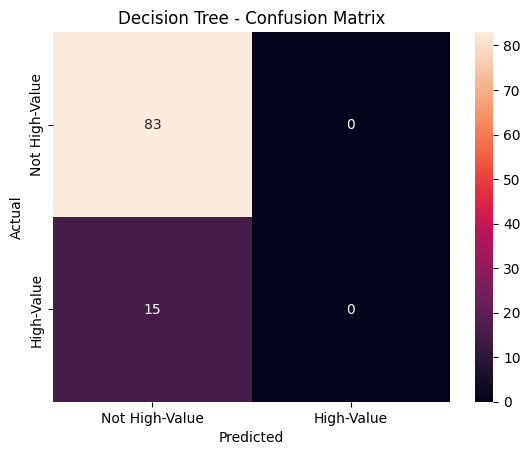

In [17]:
# Confusion Matrix for Decision Tree
dt_pred = dt_clf.predict(X_test)
cm_dt   = metrics.confusion_matrix(y_test, dt_pred)

sns.heatmap(cm_dt,
            annot=True,
            fmt='d',
            xticklabels=['Not High-Value', 'High-Value'],
            yticklabels=['Not High-Value', 'High-Value'])
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show();

In [18]:
# Classification Report for Decision Tree
print(metrics.classification_report(y_test, dt_pred,
                                    labels=[0],
                                    target_names=['Not High-Value']))

                precision    recall  f1-score   support

Not High-Value       0.85      1.00      0.92        83

     micro avg       0.85      1.00      0.92        83
     macro avg       0.85      1.00      0.92        83
  weighted avg       0.85      1.00      0.92        83



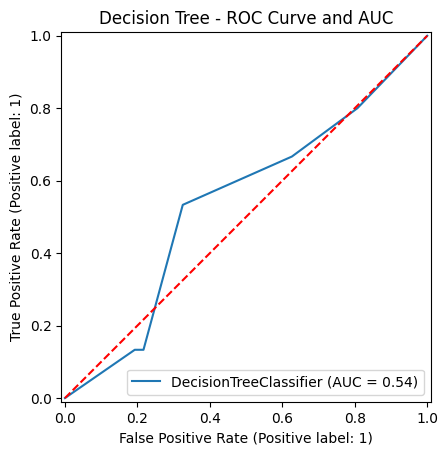

In [19]:
# plot the ROC curve using RocCurveDisplay
RocCurveDisplay.from_estimator(dt_clf,
                               X_test,
                               y_test)
plt.plot([0,1],[0,1],'r--')
plt.title('Decision Tree - ROC Curve and AUC')
plt.show();

In [20]:
# Get the predicted class labels
preds        = dt_clf.predict(X = X_test)
preds_class  = pd.DataFrame(preds)
preds_class.columns = ['Prediction']

# Get the probability
preds_prob = dt_clf.predict_proba(X = X_test)
preds_prob = pd.DataFrame(preds_prob,
                          columns=['Not High-Value', 'High-Value'])

# Actual CLV outcome
original_result = pd.DataFrame(y_test.values)
original_result.columns = ['Original Result']

# Merge the three dataframes together
# 0: Not High-Value
# 1: High-Value
result_dt = pd.concat([preds_prob, preds_class, original_result], axis=1)
result_dt.head()

,Not High-Value,High-Value,Prediction,Original Result
0,0.697674,0.302326,0,0
1,0.697674,0.302326,0,0
2,0.945946,0.054054,0,0
3,0.975610,0.024390,0,0
4,0.975610,0.024390,0,0


In [21]:
# Build and fit the Logistic Regression classifier
lr_clf = LogisticRegression(max_iter=1000, random_state=1)
lr_clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [22]:
# Classification Report for Logistic Regression
lr_pred = lr_clf.predict(X_test)
print(metrics.classification_report(y_test, lr_pred,
                                    labels=[0],
                                    target_names=['Not High-Value']))

                precision    recall  f1-score   support

Not High-Value       0.85      1.00      0.92        83

     micro avg       0.85      1.00      0.92        83
     macro avg       0.85      1.00      0.92        83
  weighted avg       0.85      1.00      0.92        83



In [23]:
# Classification Report for Logistic Regression
lr_pred = lr_clf.predict(X_test)
print(metrics.classification_report(y_test, lr_pred,
                                    labels=[0],
                                    target_names=['Not High-Value']))

                precision    recall  f1-score   support

Not High-Value       0.85      1.00      0.92        83

     micro avg       0.85      1.00      0.92        83
     macro avg       0.85      1.00      0.92        83
  weighted avg       0.85      1.00      0.92        83



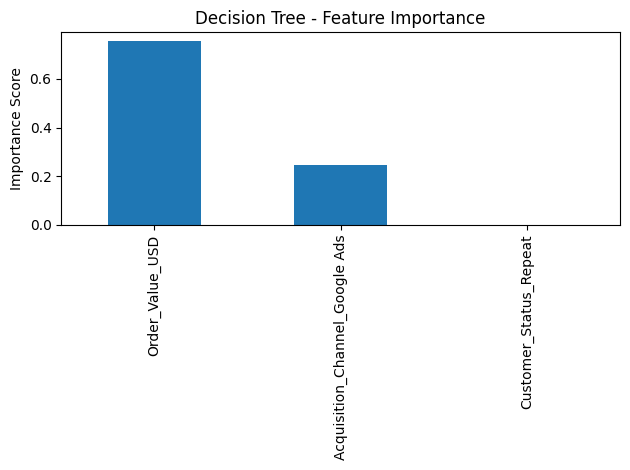

In [24]:
# Feature importance from Decision Tree
dt_importance = pd.Series(dt_clf.feature_importances_, index=cols)
dt_importance.sort_values(ascending=False).plot(kind='bar')
plt.title('Decision Tree - Feature Importance')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show();

## Model 2: Logistic Regression

### Fit the model

In [25]:
# Build and fit the Logistic Regression classifier
lr_clf = LogisticRegression(max_iter=1000, random_state=1)
lr_clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

### Evaluate the Logistic Regression model

In [26]:
# Accuracy on training data
print("Logistic Regression Training Accuracy:", lr_clf.score(X_train, y_train))

Logistic Regression Training Accuracy: 0.8458904109589042


In [27]:
# Accuracy on testing data
print("Logistic Regression Testing Accuracy:", lr_clf.score(X_test, y_test))

Logistic Regression Testing Accuracy: 0.8469387755102041


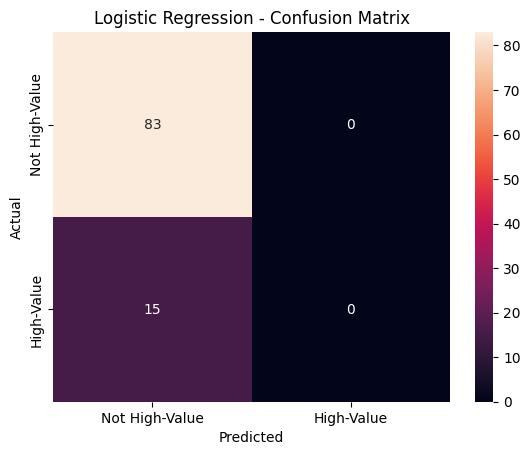

In [28]:
# Confusion Matrix for Logistic Regression
lr_pred = lr_clf.predict(X_test)
cm_lr   = metrics.confusion_matrix(y_test, lr_pred)

sns.heatmap(cm_lr,
            annot=True,
            fmt='d',
            xticklabels=['Not High-Value', 'High-Value'],
            yticklabels=['Not High-Value', 'High-Value'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show();

In [29]:
# Classification Report for Logistic Regression
lr_pred = lr_clf.predict(X_test)
print(metrics.classification_report(y_test, lr_pred,
                                    labels=[0],
                                    target_names=['Not High-Value']))

                precision    recall  f1-score   support

Not High-Value       0.85      1.00      0.92        83

     micro avg       0.85      1.00      0.92        83
     macro avg       0.85      1.00      0.92        83
  weighted avg       0.85      1.00      0.92        83



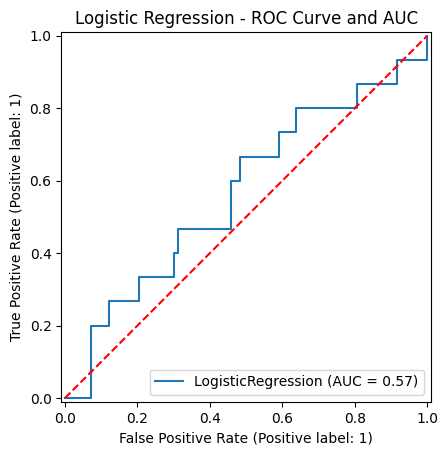

In [30]:
# plot the ROC curve using RocCurveDisplay
RocCurveDisplay.from_estimator(lr_clf,
                               X_test,
                               y_test)
plt.plot([0,1],[0,1],'r--')
plt.title('Logistic Regression - ROC Curve and AUC')
plt.show();

In [31]:
# Get the predicted class labels
preds_lr       = lr_clf.predict(X = X_test)
preds_class_lr = pd.DataFrame(preds_lr)
preds_class_lr.columns = ['Prediction']

# Get the probability
preds_prob_lr = lr_clf.predict_proba(X = X_test)
preds_prob_lr = pd.DataFrame(preds_prob_lr,
                              columns=['Not High-Value', 'High-Value'])

# Actual CLV outcome
original_result_lr = pd.DataFrame(y_test.values)
original_result_lr.columns = ['Original Result']

# Merge the three dataframes together ---
# 0: Not High-Value
# 1: High-Value
result_lr = pd.concat([preds_prob_lr, preds_class_lr, original_result_lr], axis=1)
result_lr.head()

,Not High-Value,High-Value,Prediction,Original Result
0,0.797053,0.202947,0,0
1,0.794850,0.205150,0,0
2,0.802367,0.197633,0,0
3,0.913682,0.086318,0,0
4,0.887109,0.112891,0,0


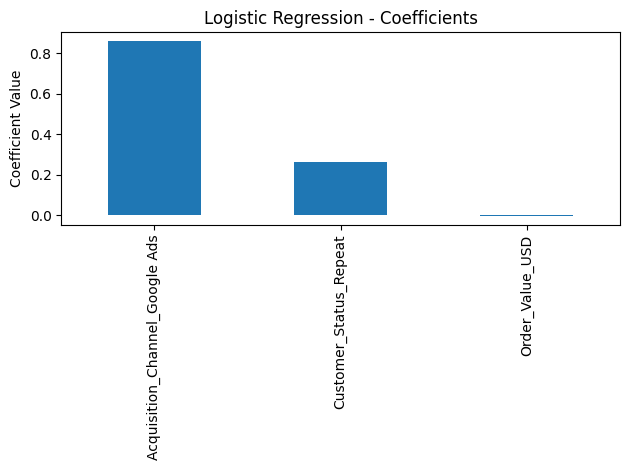

In [32]:
# Logistic Regression Coefficients
lr_coef = pd.Series(lr_clf.coef_[0], index=cols)
lr_coef.sort_values(ascending=False).plot(kind='bar')
plt.title('Logistic Regression - Coefficients')
plt.ylabel('Coefficient Value')
plt.tight_layout()
plt.show();

## Comparison between the Two Models

In [33]:
# Compare accuracy of both models
print("=== Model Performance Comparison ===")
print(f"Decision Tree  - Training Accuracy: {dt_clf.score(X_train, y_train):.4f}")
print(f"Decision Tree  - Testing  Accuracy: {dt_clf.score(X_test,  y_test):.4f}")
print(f"Logistic Reg.  - Training Accuracy: {lr_clf.score(X_train, y_train):.4f}")
print(f"Logistic Reg.  - Testing  Accuracy: {lr_clf.score(X_test,  y_test):.4f}")

=== Model Performance Comparison ===
Decision Tree  - Training Accuracy: 0.8527
Decision Tree  - Testing  Accuracy: 0.8469
Logistic Reg.  - Training Accuracy: 0.8459
Logistic Reg.  - Testing  Accuracy: 0.8469


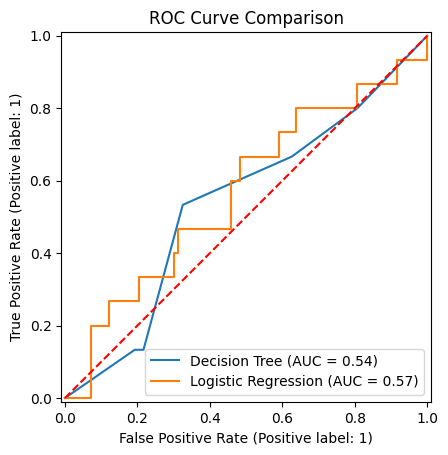

In [34]:
# -- Plot both ROC curves together for visual comparison --
fig, ax = plt.subplots()

RocCurveDisplay.from_estimator(dt_clf, X_test, y_test, ax=ax, name='Decision Tree')
RocCurveDisplay.from_estimator(lr_clf, X_test, y_test, ax=ax, name='Logistic Regression')
plt.plot([0,1],[0,1],'r--')
plt.title('ROC Curve Comparison')
plt.show();

## Comparison between predicted CLV and actual CLV

In [35]:
# Decision Tree: predicted vs actual
result_dt.head()

,Not High-Value,High-Value,Prediction,Original Result
0,0.697674,0.302326,0,0
1,0.697674,0.302326,0,0
2,0.945946,0.054054,0,0
3,0.975610,0.024390,0,0
4,0.975610,0.024390,0,0


In [36]:
# Logistic Regression: predicted vs actual
result_lr.head()

,Not High-Value,High-Value,Prediction,Original Result
0,0.797053,0.202947,0,0
1,0.794850,0.205150,0,0
2,0.802367,0.197633,0,0
3,0.913682,0.086318,0,0
4,0.887109,0.112891,0,0


# Short reflection:
- ## Compare the performance between the logistic regression model and the decision tree model
The two classification models (Decision Tree and Logistic Regression) were developed to predict high value customers. **Both achieved identical test-set accuracy of 84.69%.** The Decision Tree exhibited slightly higher training accuracy (85.27% vs. 84.59%) and mild overfitting, while Logistic Regression demonstrated greater stability. However, both models produced low AUC values (0.57 for Logistic Regression, 0.54 for Decision Tree), indicating limited discriminative ability.
The low AUC is primarily explained by severe class imbalance in the dataset, where high-value customers represent a small minority. **This imbalance is expected given NovaHome’s positioning as a budget friendly retailer** where most transactions fall in the $40–$110 range, with relatively few customers quickly progressing to high lifetime spend. In contrast, a luxury furniture brand would likely exhibit a more balanced or even inverse class distribution due to higher average order values and faster progression to repeat or high-spend behavior. Neither model identified strong predictors beyond acquisition channel, underscoring the need for additonal feature engineering in future iterations.

- ## Do these two models suggest different insights regarding predictors?
The models show nearly identical insights regarding predictors, the aqusition channel itself was the strongest predictor of high value customers. Both models have low AUC indicating a low seperation ability between clases, most likley due to the class imbalance that is expected in a budget friendly retailers transaction history.
- ## Summarize your discussion regard discussion questions
Analysis of ad performance, web traffic, transaction data, and predictive modeling reveals a clear performance advantage for Google channels, particularly Shopping and Generic Search, in both volume and quality of conversions. Facebook campaigns delivered significantly lower conversion rates and contributed far fewer high-value customers. These patterns align with the business model of offering affordable home décor and small furniture to urban millennials, where purchase intent is a critical driver of efficiency.

- ## Daily Performance Trends
Daily conversions ranged from **8 to 47**, with peaks observed on **September 25 (47), September 30 (45), and September 3 (38)**. No consistent weekly seasonality (e.g., weekday vs. weekend effects) was evident over the 30-day window. Facebook-specific metrics showed notable day-to-day variability in conversion rate (CVR), bounce rate, and page load time, with several days falling below the 0.6% CVR threshold. This volatility is consistent with impulse-driven purchasing behavior typical of the target demographic, where decisions are often triggered by immediate needs or visual inspiration rather than planned shopping cycles.

#### Campaign Performance Comparison
Google campaigns significantly outperformed Meta campaigns across key metrics:

**Google Shopping: 258 conversions** 
**Google Search Generic: 255 conversions**
**Google Search Branded: 218 conversions**
**Facebook Lookalike: 42 conversions**
**Facebook Retargeting: 29 conversions**

Total conversions from Google exceeded 730, compared with 71 from Facebook, despite comparable spend levels in some cases. The performance differential is attributable to channel mechanics: Google Search and Shopping capture high-intent users actively researching or ready to purchase home décor items, whereas Facebook Lookalike and Retargeting audiences are broader and lower-intent, resulting in higher browse-to-buy drop-off.
#### Contribution to High-Value Customers
Google channels generated the large majority of total conversions and therefore the preponderance of high-value customers (CLV_Flag = Yes). High-value customers were substantially more likely to originate from Google than from Facebook. This outcome reflects the stronger purchase intent associated with search-based discovery, which increases the probability of repeat purchases and higher lifetime spend among budget-conscious millennials gradually furnishing their living spaces.

#### Budget Reallocation Recommendation for October 2025
##### If an additonal $10,000 be allocated in the budget for advertising, the following actions should be taken:


**Recomended Actions:**

- Increase allocation to Google Shopping and Google Search Generic, which delivered the highest volume and efficiency.
- Maintain or slightly reduce Google Search Branded spend.
- Significantly reduce investment in Facebook Lookalike campaigns due to low conversion volume and quality.
- Retain a limited budget for Facebook Retargeting to capture warm audiences, but at a reduced level.

<br> Prior to the holday season, NovaHome, should allocate the additonal marketing budget by following our recomendations and NovaHome can expect to improve overall ROAS and accelerate high-value customer acquisition